# 📓 Notebook 01 — Preprocessing & Augmentasi
**Spendly AI — Coding Camp 2026 powered by DBS Foundation (CC26-PSU276)**

Pipeline:
1. Kumpulkan semua gambar dari folder kelas
2. Split ulang stratified 70/15/15
3. Definisikan & verifikasi pipeline augmentasi
4. Equalisasi kelas via offline augmentation (target 200/kelas)
5. Visualisasi distribusi & verifikasi data leakage

## 1.0 — Setup & Imports

In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import albumentations as A
from sklearn.model_selection import train_test_split
from collections import Counter
import shutil
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Project paths (relative)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
CSV_DIR = os.path.join(DATA_DIR, '_csv')
PROCESSED_DIR = os.path.join(DATA_DIR, '_processed')

os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

CLASSES = ['Beauty', 'F&B', 'Gas', 'Groceries', 'Health', 'HouseHold', 'Lifestyle', 'Listrik', 'transport']
IMG_EXTENSIONS = ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp')

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Dir: {DATA_DIR}")
print(f"Classes: {CLASSES}")

Project Root: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace
Data Dir: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\data
Classes: ['Beauty', 'F&B', 'Gas', 'Groceries', 'Health', 'HouseHold', 'Lifestyle', 'Listrik', 'transport']


In [2]:
import subprocess
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print(f"Jumlah GPU terdeteksi TF: {len(gpus)}")
for gpu in gpus:
    print(f"  Device: {gpu.name}")

try:
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=index,name,memory.total,memory.free', '--format=csv,noheader'],
        capture_output=True, text=True
    )
    print("\nnvidia-smi GPU info:")
    for line in result.stdout.strip().split('\n'):
        print(f"  {line}")
except Exception as e:
    print(f"nvidia-smi tidak tersedia: {e}")

print(f"\nGPU aktif untuk TF: {tf.test.gpu_device_name()}")


Jumlah GPU terdeteksi TF: 1
  Device: /physical_device:GPU:0

nvidia-smi GPU info:
  0, NVIDIA GeForce RTX 3060 Ti, 8192 MiB, 6770 MiB

GPU aktif untuk TF: /device:GPU:0


## 1.1 — Kumpulkan Semua Gambar & Split Ulang

In [3]:
# Collect ALL images from each class (ignoring old train/val/test structure)
all_filepaths = []
all_labels = []

for cls in CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    if not os.path.exists(cls_dir):
        print(f"⚠️ Folder tidak ditemukan: {cls_dir}")
        continue
    
    # Recursively find all image files
    images = []
    for ext in IMG_EXTENSIONS:
        images.extend(glob.glob(os.path.join(cls_dir, '**', ext), recursive=True))
    
    # Filter: only files in 'images' subdirectories (exclude labels)
    images = [f for f in images if 'labels' not in f.replace('/', os.sep).replace('\\', os.sep)]
    
    print(f"  {cls:12s}: {len(images)} gambar ditemukan")
    all_filepaths.extend(images)
    all_labels.extend([cls] * len(images))

print(f"\n📊 Total gambar terkumpul: {len(all_filepaths)}")

  Beauty      : 57 gambar ditemukan
  F&B         : 141 gambar ditemukan
  Gas         : 62 gambar ditemukan
  Groceries   : 251 gambar ditemukan
  Health      : 40 gambar ditemukan
  HouseHold   : 40 gambar ditemukan
  Lifestyle   : 40 gambar ditemukan
  Listrik     : 62 gambar ditemukan
  transport   : 132 gambar ditemukan

📊 Total gambar terkumpul: 825


### Distribusi Kelas (Data Asli)


📊 Distribusi kelas (data asli):
-----------------------------------
  Beauty      :   57 ███████████
  F&B         :  141 ████████████████████████████
  Gas         :   62 ████████████
  Groceries   :  251 ██████████████████████████████████████████████████
  Health      :   40 ████████
  HouseHold   :   40 ████████
  Lifestyle   :   40 ████████
  Listrik     :   62 ████████████
  transport   :  132 ██████████████████████████
  TOTAL       :  825


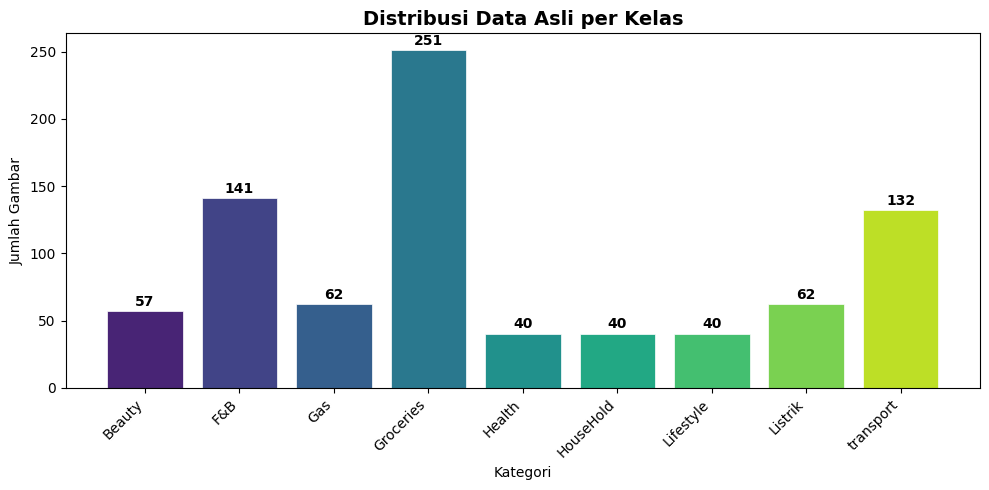

✅ Plot distribusi data asli tersimpan


In [4]:
# Show original distribution
original_counts = Counter(all_labels)
print("\n📊 Distribusi kelas (data asli):")
print("-" * 35)
for cls in CLASSES:
    count = original_counts.get(cls, 0)
    bar = '█' * (count // 5)
    print(f"  {cls:12s}: {count:4d} {bar}")
print(f"  {'TOTAL':12s}: {sum(original_counts.values()):4d}")

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("viridis", len(CLASSES))
bars = ax.bar(CLASSES, [original_counts[c] for c in CLASSES], color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Distribusi Data Asli per Kelas', fontsize=14, fontweight='bold')
ax.set_xlabel('Kategori')
ax.set_ylabel('Jumlah Gambar')
for bar, count in zip(bars, [original_counts[c] for c in CLASSES]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2, str(count),
            ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'distribusi_data_asli.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot distribusi data asli tersimpan")

### Stratified Split 70/15/15

In [5]:
# Stratified split: 70% train, 15% val, 15% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    all_filepaths, all_labels, test_size=0.15, stratify=all_labels, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, stratify=y_train_val, random_state=SEED  # 0.176 * 0.85 ≈ 0.15
)

print(f"✅ Split selesai:")
print(f"   Train: {len(X_train)} ({len(X_train)/len(all_filepaths)*100:.1f}%)")
print(f"   Val:   {len(X_val)} ({len(X_val)/len(all_filepaths)*100:.1f}%)")
print(f"   Test:  {len(X_test)} ({len(X_test)/len(all_filepaths)*100:.1f}%)")

# Per-class breakdown
print(f"\n📊 Distribusi per kelas per split:")
print(f"  {'Kelas':12s} {'Train':>6s} {'Val':>6s} {'Test':>6s} {'Total':>6s}")
print(f"  {'-'*42}")
for cls in CLASSES:
    tr = sum(1 for y in y_train if y == cls)
    va = sum(1 for y in y_val if y == cls)
    te = sum(1 for y in y_test if y == cls)
    print(f"  {cls:12s} {tr:6d} {va:6d} {te:6d} {tr+va+te:6d}")

✅ Split selesai:
   Train: 577 (69.9%)
   Val:   124 (15.0%)
   Test:  124 (15.0%)

📊 Distribusi per kelas per split:
  Kelas         Train    Val   Test  Total
  ------------------------------------------
  Beauty           39      9      9     57
  F&B              99     21     21    141
  Gas              44      9      9     62
  Groceries       175     38     38    251
  Health           28      6      6     40
  HouseHold        28      6      6     40
  Lifestyle        28      6      6     40
  Listrik          44      9      9     62
  transport        92     20     20    132


In [6]:
# Save split manifest CSV
manifest_data = []
for fp, lbl in zip(X_train, y_train):
    manifest_data.append({'filepath': fp, 'label': lbl, 'split': 'train'})
for fp, lbl in zip(X_val, y_val):
    manifest_data.append({'filepath': fp, 'label': lbl, 'split': 'val'})
for fp, lbl in zip(X_test, y_test):
    manifest_data.append({'filepath': fp, 'label': lbl, 'split': 'test'})

manifest_df = pd.DataFrame(manifest_data)
manifest_path = os.path.join(CSV_DIR, 'split_manifest.csv')
manifest_df.to_csv(manifest_path, index=False)
print(f"\n✅ Manifest CSV tersimpan: {manifest_path}")
print(f"   Total baris: {len(manifest_df)}")
print(manifest_df.head())


✅ Manifest CSV tersimpan: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\data\_csv\split_manifest.csv
   Total baris: 825
                                            filepath      label  split
0  c:\file akmal\Capstone - Ai Eng - Spendly_ Wor...  Lifestyle  train
1  c:\file akmal\Capstone - Ai Eng - Spendly_ Wor...  Groceries  train
2  c:\file akmal\Capstone - Ai Eng - Spendly_ Wor...  Groceries  train
3  c:\file akmal\Capstone - Ai Eng - Spendly_ Wor...  HouseHold  train
4  c:\file akmal\Capstone - Ai Eng - Spendly_ Wor...        F&B  train


### Visualisasi Split per Kelas

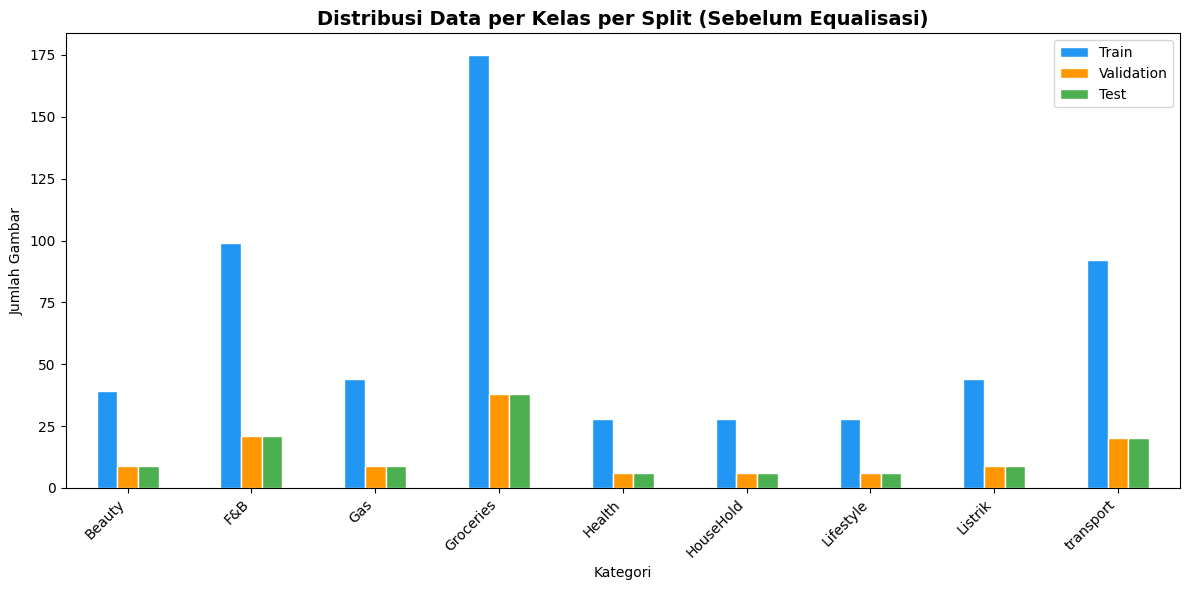

✅ Plot distribusi split (sebelum equalisasi) tersimpan


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
split_data = manifest_df.groupby(['label', 'split']).size().unstack(fill_value=0)
split_data = split_data.reindex(CLASSES)[['train', 'val', 'test']]
split_data.plot(kind='bar', ax=ax, color=['#2196F3', '#FF9800', '#4CAF50'], edgecolor='white')
ax.set_title('Distribusi Data per Kelas per Split (Sebelum Equalisasi)', fontsize=14, fontweight='bold')
ax.set_xlabel('Kategori')
ax.set_ylabel('Jumlah Gambar')
ax.legend(['Train', 'Validation', 'Test'], loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'distribusi_split_sebelum.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot distribusi split (sebelum equalisasi) tersimpan")

## 1.2 — Pipeline Augmentasi (Albumentations)

In [8]:
# Define augmentation pipeline - SAFE for receipt/document images
train_transform = A.Compose([
    A.Rotate(limit=5, border_mode=0, p=0.5),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,   # BUKAN 1.0 — ini penyebab gambar hitam sebelumnya!
        contrast_limit=0.2,
        p=0.5
    ),
    A.GaussNoise(var_limit=(5.0, 30.0), p=0.3),
    A.Blur(blur_limit=3, p=0.2),
    A.ImageCompression(quality_lower=75, quality_upper=100, p=0.2),
])

val_test_transform = None  # Tidak ada augmentasi untuk val/test

print("✅ Pipeline augmentasi terdefinisi:")
print(f"   Transforms: {len(train_transform.transforms)} operasi")
for t in train_transform.transforms:
    print(f"   - {t.__class__.__name__}")

✅ Pipeline augmentasi terdefinisi:
   Transforms: 5 operasi
   - Rotate
   - RandomBrightnessContrast
   - GaussNoise
   - Blur
   - ImageCompression


### Verifikasi Augmentasi — Grid Original + 7 Variasi

🔍 Verifikasi augmentasi untuk 3 gambar dari kelas berbeda:
  ✅ Beauty: Semua 7 augmentasi VALID (tidak ada gambar hitam)
  ✅ F&B: Semua 7 augmentasi VALID (tidak ada gambar hitam)
  ✅ Listrik: Semua 7 augmentasi VALID (tidak ada gambar hitam)


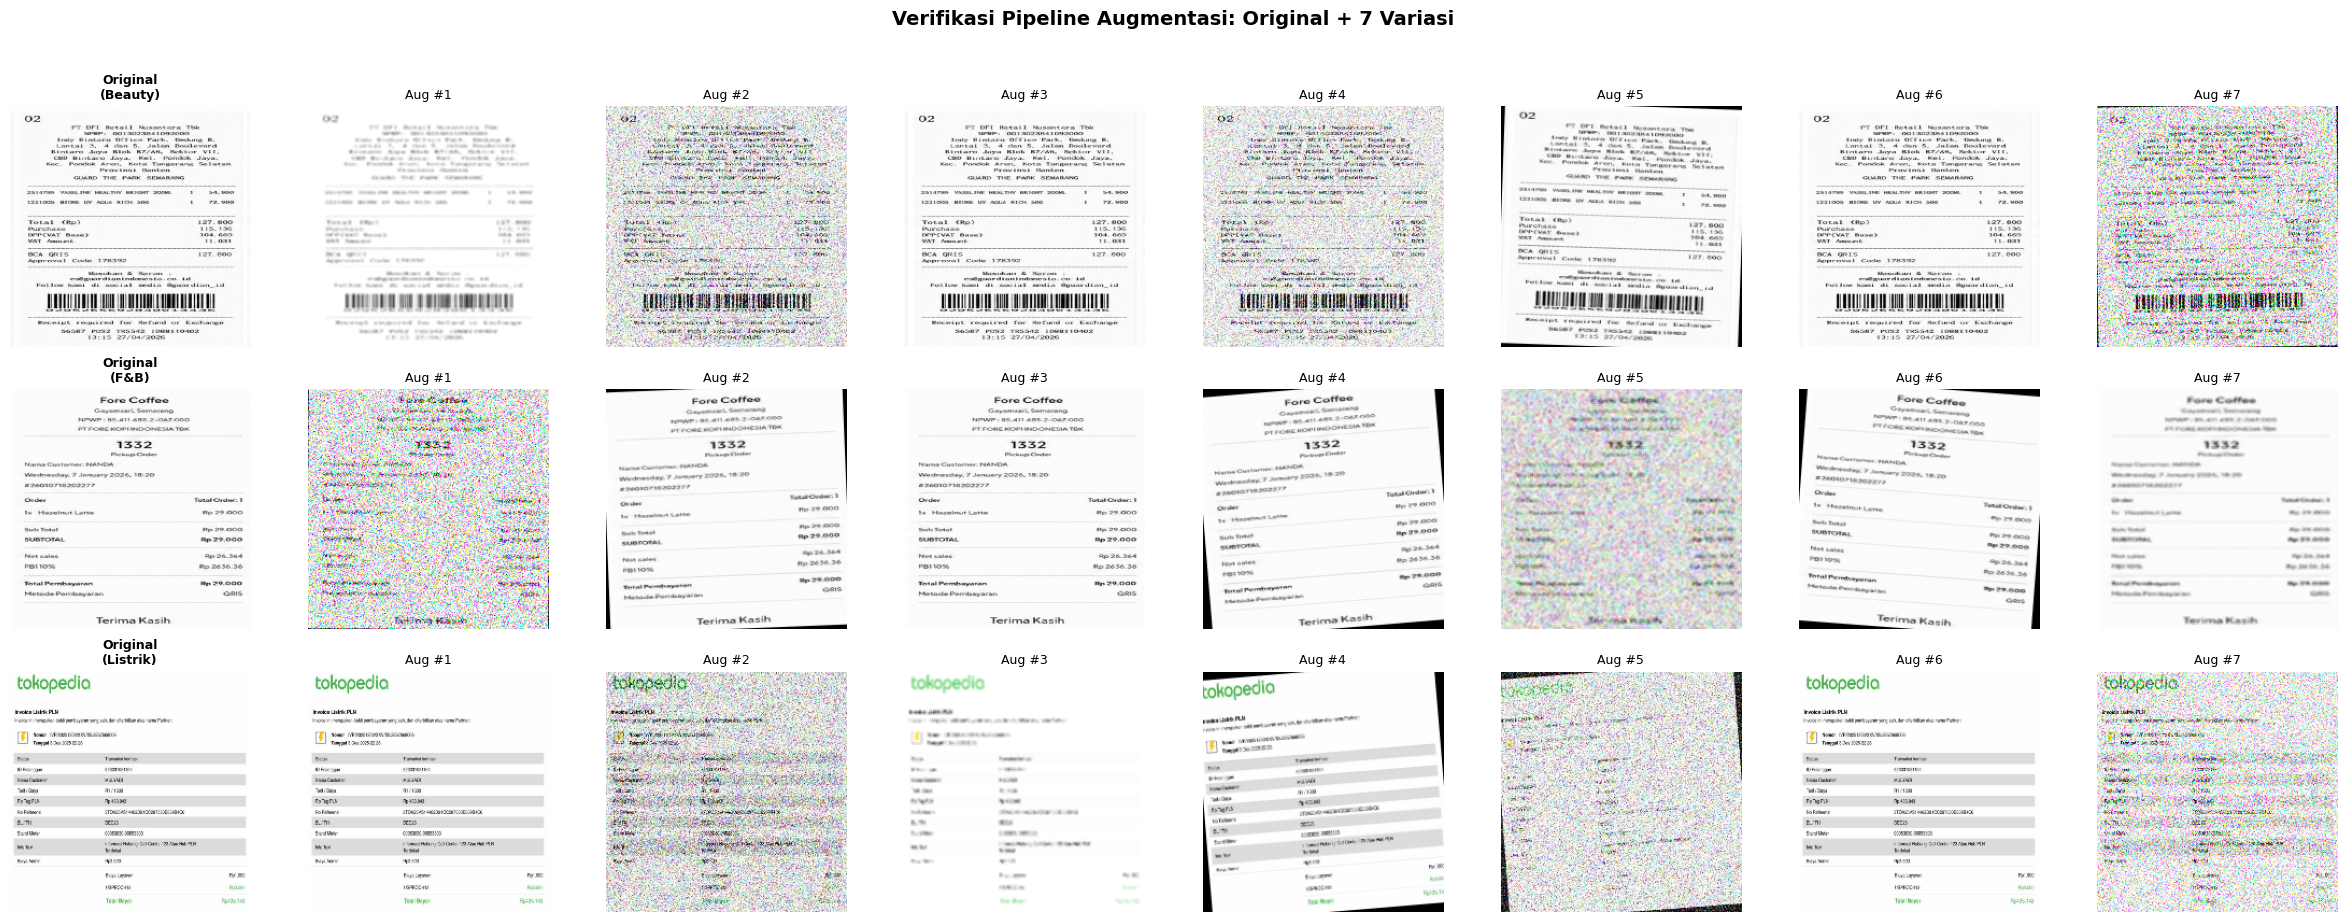


✅ Grid verifikasi augmentasi tersimpan


In [9]:
# Pick 3 sample images from different classes for verification
sample_classes = ['Beauty', 'F&B', 'Listrik']
sample_images = []
for cls in sample_classes:
    cls_images = [fp for fp, lbl in zip(X_train, y_train) if lbl == cls]
    if cls_images:
        sample_images.append((cls, cls_images[0]))

print(f"🔍 Verifikasi augmentasi untuk {len(sample_images)} gambar dari kelas berbeda:")

fig, axes = plt.subplots(len(sample_images), 8, figsize=(24, 3*len(sample_images)))

for row_idx, (cls, img_path) in enumerate(sample_images):
    # Load original image
    img = cv2.imread(img_path)
    if img is None:
        print(f"  ⚠️ Gagal memuat: {img_path}")
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))
    
    # Show original
    axes[row_idx, 0].imshow(img_resized)
    axes[row_idx, 0].set_title(f'Original\n({cls})', fontsize=9, fontweight='bold')
    axes[row_idx, 0].axis('off')
    
    # Generate 7 augmented versions
    black_count = 0
    for aug_idx in range(7):
        augmented = train_transform(image=img_resized)['image']
        
        # Check for black image
        if augmented.mean() < 5:
            black_count += 1
            print(f"  ⚠️ GAMBAR HITAM terdeteksi! Kelas: {cls}, augmentasi #{aug_idx+1}")
        
        axes[row_idx, aug_idx + 1].imshow(augmented)
        axes[row_idx, aug_idx + 1].set_title(f'Aug #{aug_idx+1}', fontsize=9)
        axes[row_idx, aug_idx + 1].axis('off')
    
    if black_count == 0:
        print(f"  ✅ {cls}: Semua 7 augmentasi VALID (tidak ada gambar hitam)")
    else:
        print(f"  ❌ {cls}: {black_count}/7 gambar HITAM!")

plt.suptitle('Verifikasi Pipeline Augmentasi: Original + 7 Variasi', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'verifikasi_augmentasi.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Grid verifikasi augmentasi tersimpan")

## 1.3 — Equalisasi Jumlah Data per Kelas (Offline Augmentation)

**Target: 200 gambar per kelas di split train**

In [10]:
TARGET_PER_CLASS = 200

# Get train data per class
train_df = manifest_df[manifest_df['split'] == 'train'].copy()
train_counts = train_df['label'].value_counts()

print(f"📊 Strategi equalisasi (target: {TARGET_PER_CLASS}/kelas):")
print(f"  {'Kelas':12s} {'Asli':>6s} {'Target':>7s} {'Aksi':>20s}")
print(f"  {'-'*50}")

for cls in CLASSES:
    current = train_counts.get(cls, 0)
    if current >= TARGET_PER_CLASS:
        action = f"Subsample {current}→{TARGET_PER_CLASS}"
    else:
        action = f"Augment {current}→{TARGET_PER_CLASS}"
    print(f"  {cls:12s} {current:6d} {TARGET_PER_CLASS:7d} {action:>20s}")

📊 Strategi equalisasi (target: 200/kelas):
  Kelas          Asli  Target                 Aksi
  --------------------------------------------------
  Beauty           39     200       Augment 39→200
  F&B              99     200       Augment 99→200
  Gas              44     200       Augment 44→200
  Groceries       175     200      Augment 175→200
  Health           28     200       Augment 28→200
  HouseHold        28     200       Augment 28→200
  Lifestyle        28     200       Augment 28→200
  Listrik          44     200       Augment 44→200
  transport        92     200       Augment 92→200


In [11]:
# Perform offline augmentation
augmented_records = []

for cls in CLASSES:
    cls_train = train_df[train_df['label'] == cls]
    cls_files = cls_train['filepath'].tolist()
    n_current = len(cls_files)
    
    # Create output directory
    cls_out_dir = os.path.join(PROCESSED_DIR, cls, 'train')
    os.makedirs(cls_out_dir, exist_ok=True)
    
    if n_current >= TARGET_PER_CLASS:
        # Subsample
        selected = random.sample(cls_files, TARGET_PER_CLASS)
        for fp in selected:
            augmented_records.append({'filepath': fp, 'label': cls, 'split': 'train', 'augmented': False})
        print(f"  ✅ {cls:12s}: Subsampled {n_current} → {TARGET_PER_CLASS}")
    else:
        # Keep all originals
        for fp in cls_files:
            augmented_records.append({'filepath': fp, 'label': cls, 'split': 'train', 'augmented': False})
        
        # Augment to reach target
        n_needed = TARGET_PER_CLASS - n_current
        aug_count = 0
        
        while aug_count < n_needed:
            # Pick random source image
            src_path = random.choice(cls_files)
            img = cv2.imread(src_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img, (224, 224))
            
            # Apply augmentation
            augmented = train_transform(image=img_resized)['image']
            
            # Skip if black
            if augmented.mean() < 5:
                continue
            
            # Save augmented image
            aug_filename = f"aug_{cls}_{aug_count:04d}.jpg"
            aug_path = os.path.join(cls_out_dir, aug_filename)
            cv2.imwrite(aug_path, cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR))
            
            augmented_records.append({'filepath': aug_path, 'label': cls, 'split': 'train', 'augmented': True})
            aug_count += 1
        
        print(f"  ✅ {cls:12s}: Augmented {n_current} + {n_needed} = {TARGET_PER_CLASS}")

# Add val and test data (unchanged)
val_df = manifest_df[manifest_df['split'] == 'val'].copy()
test_df = manifest_df[manifest_df['split'] == 'test'].copy()

for _, row in val_df.iterrows():
    augmented_records.append({'filepath': row['filepath'], 'label': row['label'], 'split': 'val', 'augmented': False})
for _, row in test_df.iterrows():
    augmented_records.append({'filepath': row['filepath'], 'label': row['label'], 'split': 'test', 'augmented': False})

# Save updated manifest
final_manifest = pd.DataFrame(augmented_records)
final_manifest_path = os.path.join(CSV_DIR, 'split_manifest.csv')
final_manifest.to_csv(final_manifest_path, index=False)

print(f"\n✅ Manifest CSV terupdate: {final_manifest_path}")
print(f"   Total baris: {len(final_manifest)}")

  ✅ Beauty      : Augmented 39 + 161 = 200
  ✅ F&B         : Augmented 99 + 101 = 200
  ✅ Gas         : Augmented 44 + 156 = 200
  ✅ Groceries   : Augmented 175 + 25 = 200
  ✅ Health      : Augmented 28 + 172 = 200
  ✅ HouseHold   : Augmented 28 + 172 = 200
  ✅ Lifestyle   : Augmented 28 + 172 = 200
  ✅ Listrik     : Augmented 44 + 156 = 200
  ✅ transport   : Augmented 92 + 108 = 200

✅ Manifest CSV terupdate: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\data\_csv\split_manifest.csv
   Total baris: 2048


## 1.4 — Verifikasi & Laporan Distribusi

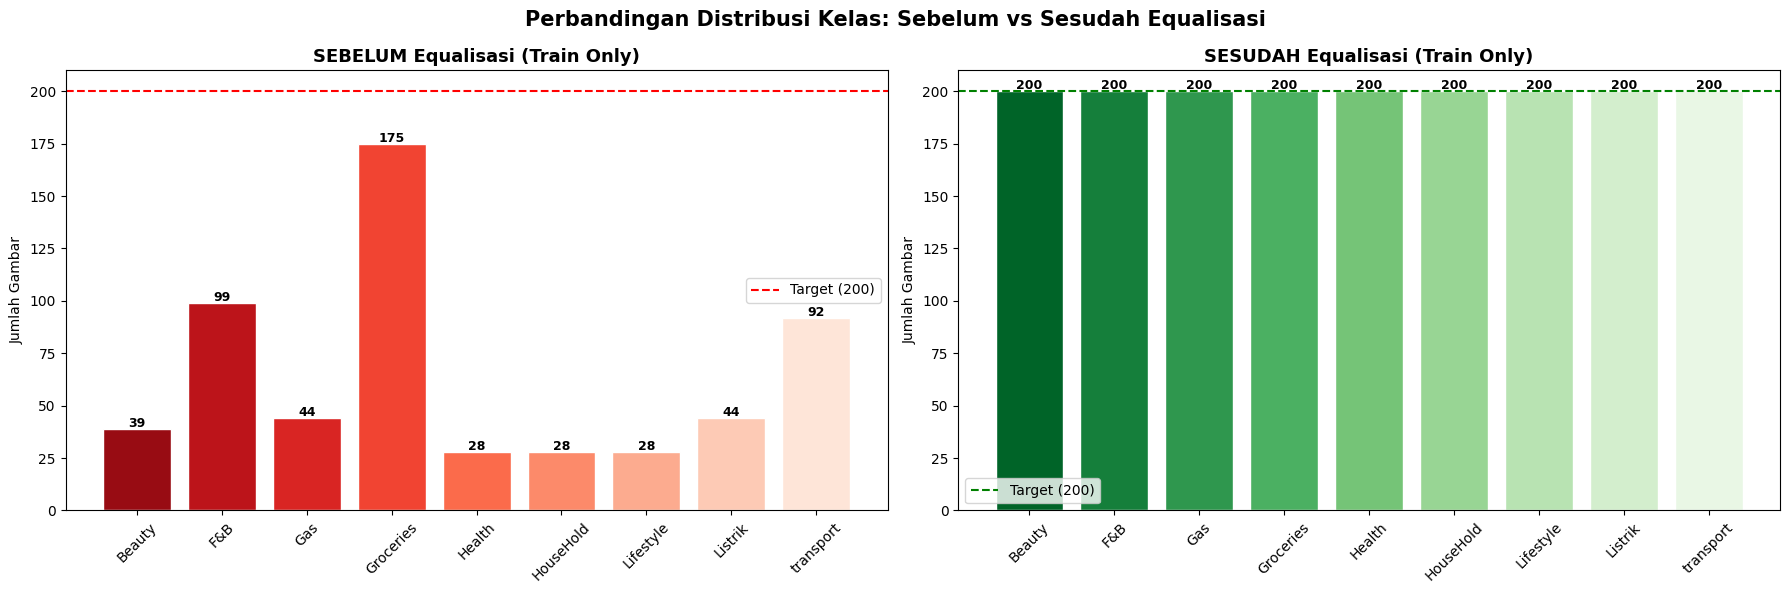

In [12]:
# Distribution after equalization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# BEFORE
before_train = train_df['label'].value_counts().reindex(CLASSES, fill_value=0)
colors_before = sns.color_palette("Reds_r", len(CLASSES))
axes[0].bar(CLASSES, before_train.values, color=colors_before, edgecolor='white')
axes[0].set_title('SEBELUM Equalisasi (Train Only)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Gambar')
for i, v in enumerate(before_train.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=9)
axes[0].axhline(y=TARGET_PER_CLASS, color='red', linestyle='--', label=f'Target ({TARGET_PER_CLASS})')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# AFTER
after_train = final_manifest[final_manifest['split'] == 'train']['label'].value_counts().reindex(CLASSES, fill_value=0)
colors_after = sns.color_palette("Greens_r", len(CLASSES))
axes[1].bar(CLASSES, after_train.values, color=colors_after, edgecolor='white')
axes[1].set_title('SESUDAH Equalisasi (Train Only)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Gambar')
for i, v in enumerate(after_train.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=9)
axes[1].axhline(y=TARGET_PER_CLASS, color='green', linestyle='--', label=f'Target ({TARGET_PER_CLASS})')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Perbandingan Distribusi Kelas: Sebelum vs Sesudah Equalisasi', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'distribusi_sebelum_sesudah.png'), dpi=150, bbox_inches='tight')
plt.show()

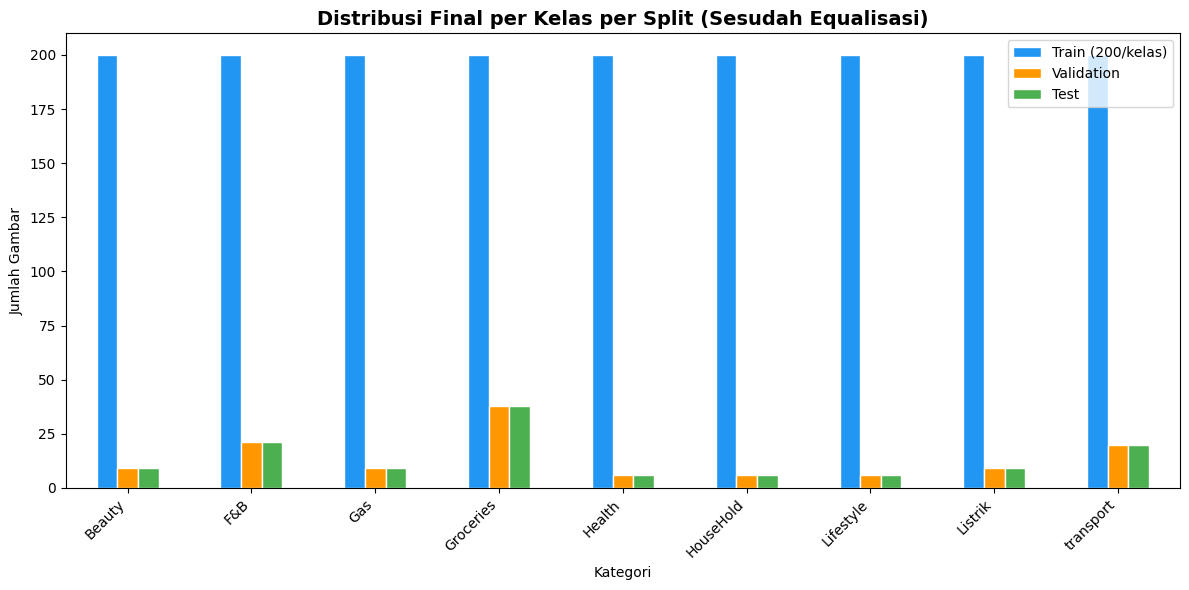

In [13]:
# Full distribution chart (all splits after equalization)
fig, ax = plt.subplots(figsize=(12, 6))
split_data_after = final_manifest.groupby(['label', 'split']).size().unstack(fill_value=0)
split_data_after = split_data_after.reindex(CLASSES)[['train', 'val', 'test']]
split_data_after.plot(kind='bar', ax=ax, color=['#2196F3', '#FF9800', '#4CAF50'], edgecolor='white')
ax.set_title('Distribusi Final per Kelas per Split (Sesudah Equalisasi)', fontsize=14, fontweight='bold')
ax.set_xlabel('Kategori')
ax.set_ylabel('Jumlah Gambar')
ax.legend(['Train (200/kelas)', 'Validation', 'Test'], loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'distribusi_final.png'), dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Summary statistics
print("\n" + "="*60)
print("📊 RINGKASAN DISTRIBUSI FINAL")
print("="*60)

for split_name in ['train', 'val', 'test']:
    split_df = final_manifest[final_manifest['split'] == split_name]
    print(f"\n  {split_name.upper()} ({len(split_df)} total):")
    for cls in CLASSES:
        n = len(split_df[split_df['label'] == cls])
        aug = len(split_df[(split_df['label'] == cls) & (split_df['augmented'] == True)]) if 'augmented' in split_df.columns else 0
        orig = n - aug
        print(f"    {cls:12s}: {n:4d} (asli: {orig}, augmented: {aug})")


📊 RINGKASAN DISTRIBUSI FINAL

  TRAIN (1800 total):
    Beauty      :  200 (asli: 39, augmented: 161)
    F&B         :  200 (asli: 99, augmented: 101)
    Gas         :  200 (asli: 44, augmented: 156)
    Groceries   :  200 (asli: 175, augmented: 25)
    Health      :  200 (asli: 28, augmented: 172)
    HouseHold   :  200 (asli: 28, augmented: 172)
    Lifestyle   :  200 (asli: 28, augmented: 172)
    Listrik     :  200 (asli: 44, augmented: 156)
    transport   :  200 (asli: 92, augmented: 108)

  VAL (124 total):
    Beauty      :    9 (asli: 9, augmented: 0)
    F&B         :   21 (asli: 21, augmented: 0)
    Gas         :    9 (asli: 9, augmented: 0)
    Groceries   :   38 (asli: 38, augmented: 0)
    Health      :    6 (asli: 6, augmented: 0)
    HouseHold   :    6 (asli: 6, augmented: 0)
    Lifestyle   :    6 (asli: 6, augmented: 0)
    Listrik     :    9 (asli: 9, augmented: 0)
    transport   :   20 (asli: 20, augmented: 0)

  TEST (124 total):
    Beauty      :    9 (asli: 

## 1.5 — Verifikasi Data Leakage

In [15]:
# Check for data leakage
train_files = set(final_manifest[final_manifest['split'] == 'train']['filepath'].values)
val_files = set(final_manifest[final_manifest['split'] == 'val']['filepath'].values)
test_files = set(final_manifest[final_manifest['split'] == 'test']['filepath'].values)

leak_train_val = train_files & val_files
leak_train_test = train_files & test_files
leak_val_test = val_files & test_files

print("🔍 Verifikasi Data Leakage:")
print(f"   Train ∩ Val:  {len(leak_train_val)} file overlap")
print(f"   Train ∩ Test: {len(leak_train_test)} file overlap")
print(f"   Val ∩ Test:   {len(leak_val_test)} file overlap")

if len(leak_train_val) == 0 and len(leak_train_test) == 0 and len(leak_val_test) == 0:
    print("   ✅ TIDAK ADA DATA LEAKAGE!")
else:
    print("   ❌ DATA LEAKAGE TERDETEKSI!")

🔍 Verifikasi Data Leakage:
   Train ∩ Val:  0 file overlap
   Train ∩ Test: 0 file overlap
   Val ∩ Test:   0 file overlap
   ✅ TIDAK ADA DATA LEAKAGE!


### Visualisasi Sample Gambar per Kelas

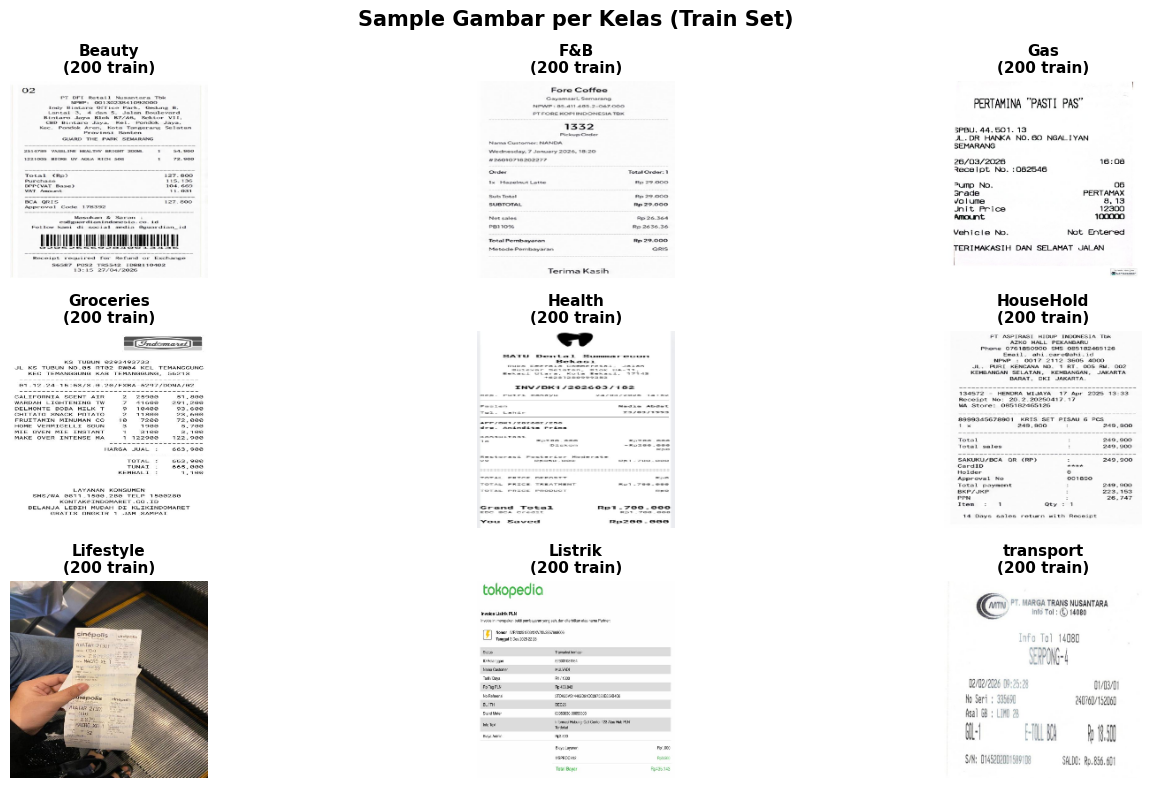

In [16]:
# Show 1 sample image per class
fig, axes = plt.subplots(3, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, cls in enumerate(CLASSES):
    cls_files = final_manifest[(final_manifest['label'] == cls) & (final_manifest['split'] == 'train')]['filepath'].values
    if len(cls_files) > 0:
        img = cv2.imread(cls_files[0])
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))
            axes[idx].imshow(img)
    axes[idx].set_title(f'{cls}\n({len(cls_files)} train)', fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Sample Gambar per Kelas (Train Set)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'sample_per_kelas.png'), dpi=150, bbox_inches='tight')
plt.show()

## 1.6 — Image Quality Assessment & Preprocessing untuk OCR

**Improvements over baseline:**
- Laplacian variance blur detection (threshold=100)
- CLAHE normalization for contrast enhancement
- Upscaling for small images (width < 800px → 2x with INTER_CUBIC)
- EasyOCR instead of Tesseract (languages: id, en)

In [17]:
!pip install easyocr


  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.


In [18]:
import re
import easyocr

# Initialize EasyOCR reader (Indonesian + English)
print("Initializing EasyOCR reader (id, en)...")
ocr_reader = easyocr.Reader(['id', 'en'], gpu=True)
print("✅ EasyOCR reader initialized")

BLUR_THRESHOLD = 100  # Laplacian variance threshold
OCR_CONFIDENCE_THRESHOLD = 0.3  # Minimum OCR confidence to keep text

def assess_image_quality(image):
    """Assess image quality using Laplacian variance for blur detection."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    is_blurry = blur_score < BLUR_THRESHOLD
    return {"blur_score": float(blur_score), "is_blurry": bool(is_blurry)}

def preprocess_for_ocr(img_path):
    """Enhanced preprocessing: CLAHE + Upscale + Deskew + Denoise."""
    img = cv2.imread(img_path)
    if img is None:
        return None, None
    
    # Assess quality first
    quality = assess_image_quality(img)
    
    # Upscale small images (width < 800px → 2x)
    h, w = img.shape[:2]
    if w < 800:
        img = cv2.resize(img, (w * 2, h * 2), interpolation=cv2.INTER_CUBIC)
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # CLAHE normalization for contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)
    
    # Deskew
    coords = np.column_stack(np.where(gray < 200))
    if len(coords) > 100:
        angle = cv2.minAreaRect(coords)[-1]
        if angle < -45:
            angle = -(90 + angle)
        else:
            angle = -angle
        if abs(angle) > 0.5 and abs(angle) < 15:
            h2, w2 = gray.shape
            M = cv2.getRotationMatrix2D((w2 // 2, h2 // 2), angle, 1.0)
            gray = cv2.warpAffine(gray, M, (w2, h2), flags=cv2.INTER_CUBIC,
                                  borderMode=cv2.BORDER_REPLICATE)
    
    # Adaptive threshold + denoise
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 11, 2)
    denoised = cv2.fastNlMeansDenoising(thresh, None, 10, 7, 21)
    
    return denoised, quality

def clean_ocr_text(text):
    """Aggressive text cleaning: remove OCR noise, barcodes, normalize."""
    if not text or not text.strip():
        return ""
    # Lowercase
    text = text.lower()
    # Remove long digit sequences (barcodes, serial numbers) — 8+ digits
    text = re.sub(r'\b\d{8,}\b', '', text)
    # Remove OCR noise characters (isolated special chars, repeated symbols)
    text = re.sub(r'[^\w\s.,;:!?/\-()%Rr]', ' ', text)
    # Remove single-character tokens (except meaningful ones like numbers)
    text = re.sub(r'\b[^0-9a-zA-Z]\b', ' ', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Initializing EasyOCR reader (id, en)...
✅ EasyOCR reader initialized


### Preprocessing Comparison: Before vs After (with CLAHE)

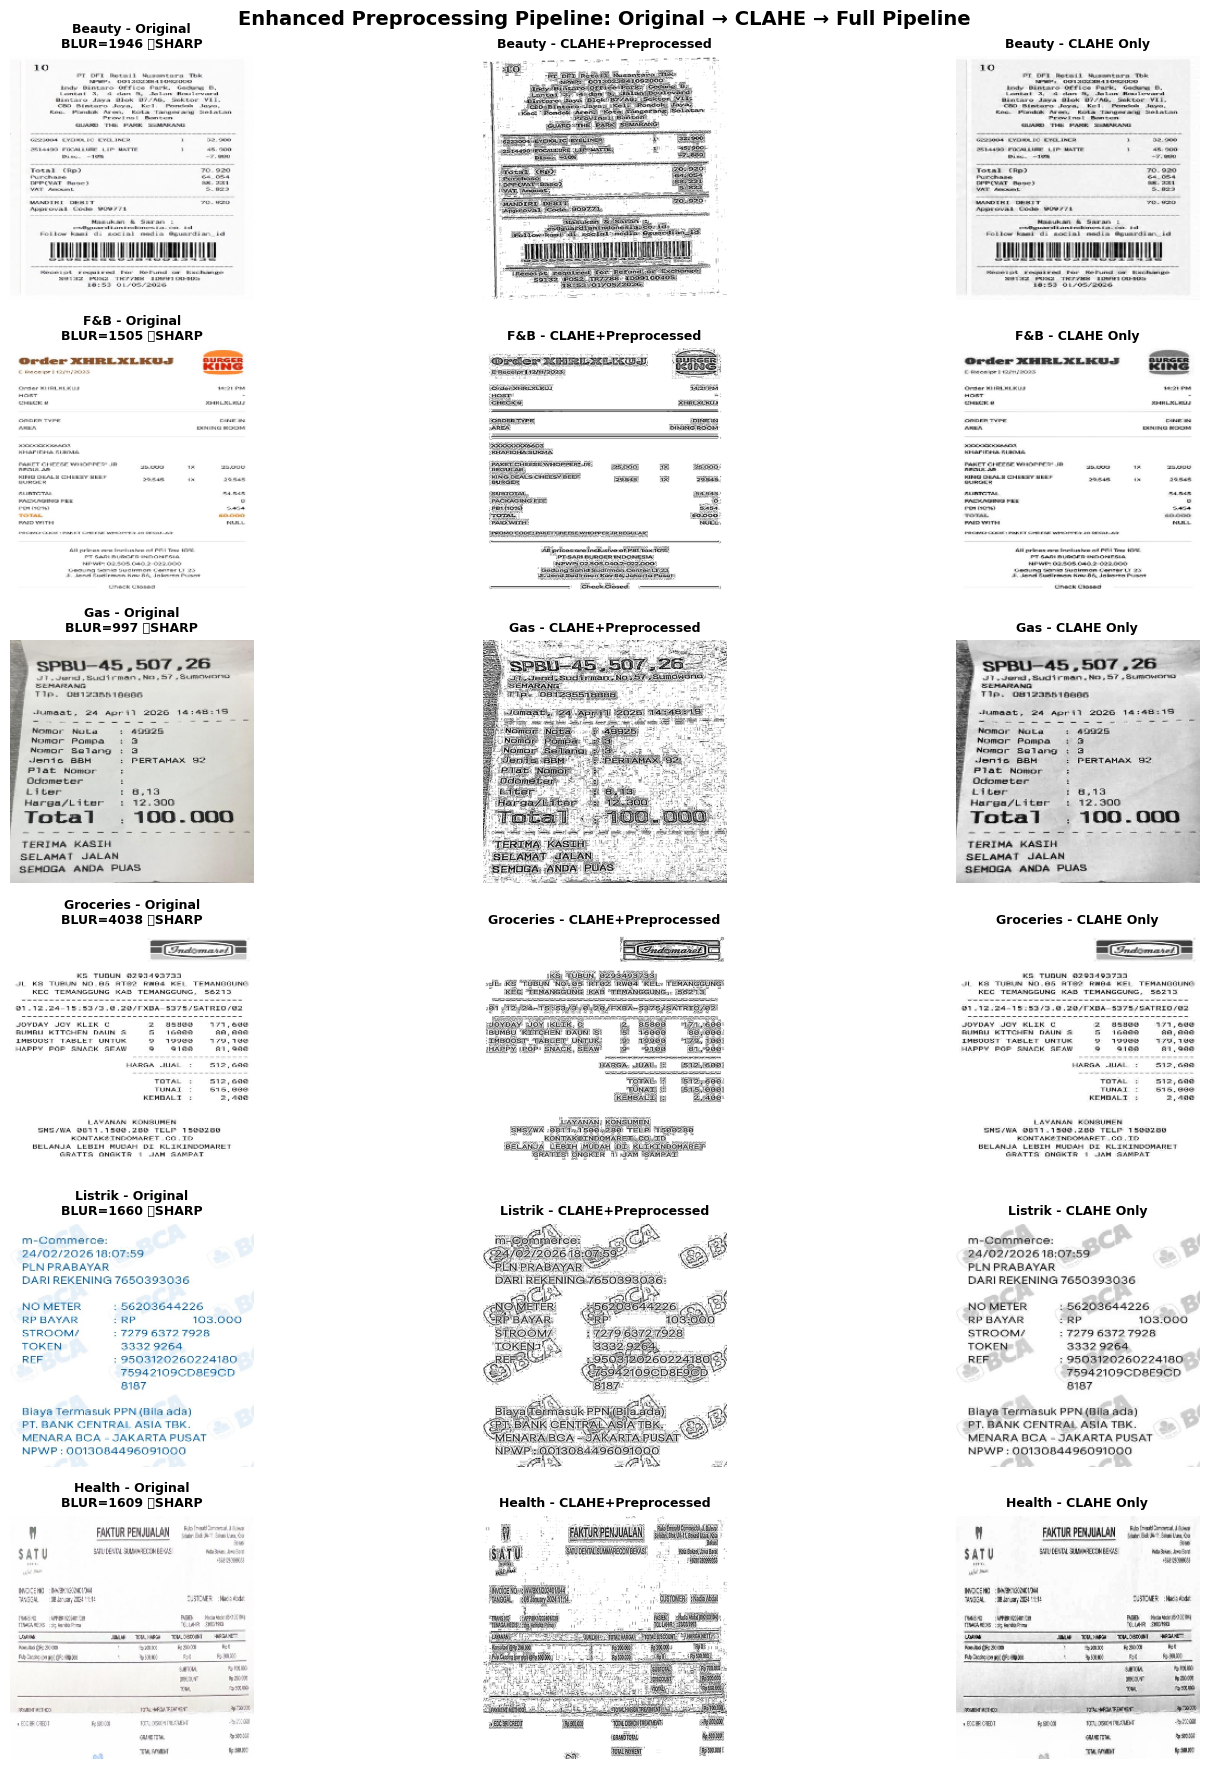

✅ Preprocessing comparison saved


In [19]:
sample_classes_ocr = ['Beauty', 'F&B', 'Gas', 'Groceries', 'Listrik', 'Health']
sample_imgs_ocr = []
for cls in sample_classes_ocr:
    cls_imgs = [fp for fp, lbl in zip(all_filepaths, all_labels) if lbl == cls]
    if cls_imgs:
        sample_imgs_ocr.append((cls, cls_imgs[0]))

fig, axes = plt.subplots(len(sample_imgs_ocr), 3, figsize=(16, 3 * len(sample_imgs_ocr)))
for i, (cls, path) in enumerate(sample_imgs_ocr):
    orig = cv2.imread(path)
    if orig is not None:
        quality = assess_image_quality(orig)
        blur_str = f"BLUR={quality['blur_score']:.0f}"
        blur_flag = " ⚠️BLURRY" if quality['is_blurry'] else " ✅SHARP"
        
        axes[i, 0].imshow(cv2.cvtColor(cv2.resize(orig, (224, 224)), cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f'{cls} - Original\n{blur_str}{blur_flag}', fontsize=9, fontweight='bold')
    axes[i, 0].axis('off')
    
    processed, _ = preprocess_for_ocr(path)
    if processed is not None:
        axes[i, 1].imshow(processed, cmap='gray')
        axes[i, 1].set_title(f'{cls} - CLAHE+Preprocessed', fontsize=9, fontweight='bold')
    axes[i, 1].axis('off')
    
    # Show CLAHE-only for comparison
    if orig is not None:
        gray = cv2.cvtColor(orig, cv2.COLOR_BGR2GRAY)
        clahe_demo = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        clahe_img = clahe_demo.apply(gray)
        axes[i, 2].imshow(cv2.resize(clahe_img, (224, 224)), cmap='gray')
        axes[i, 2].set_title(f'{cls} - CLAHE Only', fontsize=9, fontweight='bold')
    axes[i, 2].axis('off')

plt.suptitle('Enhanced Preprocessing Pipeline: Original → CLAHE → Full Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'preprocessing_before_after.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Preprocessing comparison saved")

## 1.7 — EasyOCR Extraction with Blur Detection

**Pipeline per image:**
1. Assess image quality (Laplacian variance)
2. If blurry (score < 100): skip OCR, store empty text
3. If sharp: preprocess with CLAHE → run EasyOCR → filter by confidence > 0.3
4. Clean extracted text aggressively

In [20]:
print("=" * 60)
print("Running EasyOCR on all receipt images with blur detection...")
print(f"  Total images: {len(all_filepaths)}")
print(f"  Blur threshold: {BLUR_THRESHOLD}")
print(f"  OCR confidence threshold: {OCR_CONFIDENCE_THRESHOLD}")
print("=" * 60)

ocr_results = []
skip_count = 0
error_count = 0

for i, (fp, lbl) in enumerate(zip(all_filepaths, all_labels)):
    try:
        img = cv2.imread(fp)
        if img is None:
            ocr_results.append({
                'image_path': fp, 'category': lbl, 'extracted_text': '',
                'blur_score': 0.0, 'is_blurry': True, 'ocr_confidence': 0.0
            })
            error_count += 1
            continue
        
        # Step 1: Assess image quality
        quality = assess_image_quality(img)
        
        if quality['is_blurry']:
            # Step 2: Skip OCR for blurry images
            ocr_results.append({
                'image_path': fp, 'category': lbl, 'extracted_text': '',
                'blur_score': quality['blur_score'], 'is_blurry': True,
                'ocr_confidence': 0.0
            })
            skip_count += 1
        else:
            # Step 3: Run EasyOCR on original image (EasyOCR handles preprocessing internally)
            results = ocr_reader.readtext(fp)
            
            # Filter by confidence and concatenate
            filtered_texts = []
            confidences = []
            for (bbox, text, conf) in results:
                if conf >= OCR_CONFIDENCE_THRESHOLD:
                    filtered_texts.append(text)
                    confidences.append(conf)
            
            raw_text = ' '.join(filtered_texts)
            avg_conf = float(np.mean(confidences)) if confidences else 0.0
            
            # Step 4: Clean text
            cleaned_text = clean_ocr_text(raw_text)
            
            ocr_results.append({
                'image_path': fp, 'category': lbl,
                'extracted_text': cleaned_text,
                'blur_score': quality['blur_score'],
                'is_blurry': False,
                'ocr_confidence': avg_conf
            })
    except Exception as e:
        ocr_results.append({
            'image_path': fp, 'category': lbl, 'extracted_text': '',
            'blur_score': 0.0, 'is_blurry': True, 'ocr_confidence': 0.0
        })
        error_count += 1
    
    if (i + 1) % 50 == 0:
        print(f"  Progress: {i+1}/{len(all_filepaths)} "
              f"(skipped: {skip_count}, errors: {error_count})")

dataset_text = pd.DataFrame(ocr_results)
dataset_text['text_length'] = dataset_text['extracted_text'].apply(len)
dataset_text_path = os.path.join(PROCESSED_DIR, 'dataset_text.csv')
dataset_text.to_csv(dataset_text_path, index=False)

has_text = (dataset_text['text_length'] > 0).sum()
total = len(dataset_text)
blurry_total = dataset_text['is_blurry'].sum()

print(f"\n{'=' * 60}")
print(f"EasyOCR EXTRACTION COMPLETE")
print(f"{'=' * 60}")
print(f"  Total images:     {total}")
print(f"  Blurry (skipped): {blurry_total} ({blurry_total/total*100:.1f}%)")
print(f"  Sharp (OCR'd):    {total - blurry_total} ({(total-blurry_total)/total*100:.1f}%)")
print(f"  Has text:         {has_text} ({has_text/total*100:.1f}%)")
print(f"  Errors:           {error_count}")
print(f"  Saved to:         {dataset_text_path}")

Running EasyOCR on all receipt images with blur detection...
  Total images: 825
  Blur threshold: 100
  OCR confidence threshold: 0.3
  Progress: 50/825 (skipped: 0, errors: 0)
  Progress: 100/825 (skipped: 0, errors: 0)
  Progress: 150/825 (skipped: 0, errors: 0)
  Progress: 200/825 (skipped: 1, errors: 0)
  Progress: 250/825 (skipped: 4, errors: 0)
  Progress: 300/825 (skipped: 4, errors: 0)
  Progress: 350/825 (skipped: 5, errors: 0)
  Progress: 400/825 (skipped: 5, errors: 0)
  Progress: 450/825 (skipped: 5, errors: 0)
  Progress: 500/825 (skipped: 5, errors: 0)
  Progress: 550/825 (skipped: 5, errors: 0)
  Progress: 600/825 (skipped: 5, errors: 0)
  Progress: 650/825 (skipped: 6, errors: 0)
  Progress: 700/825 (skipped: 6, errors: 0)
  Progress: 750/825 (skipped: 6, errors: 0)
  Progress: 800/825 (skipped: 6, errors: 0)

EasyOCR EXTRACTION COMPLETE
  Total images:     825
  Blurry (skipped): 6 (0.7%)
  Sharp (OCR'd):    819 (99.3%)
  Has text:         817 (99.0%)
  Errors:       

## 1.8 — Blur & OCR Statistics

In [21]:
# --- Blur statistics per category ---
print("\n📊 Blur Statistics per Category:")
print(f"  {'Category':12s} {'Total':>6s} {'Blurry':>7s} {'Sharp':>6s} {'%Blurry':>8s}")
print(f"  {'-'*45}")
blur_stats = []
for cls in CLASSES:
    cls_data = dataset_text[dataset_text['category'] == cls]
    n_total = len(cls_data)
    n_blurry = cls_data['is_blurry'].sum()
    n_sharp = n_total - n_blurry
    pct = n_blurry / n_total * 100 if n_total > 0 else 0
    blur_stats.append({'category': cls, 'total': n_total, 'blurry': n_blurry,
                       'sharp': n_sharp, 'pct_blurry': pct})
    print(f"  {cls:12s} {n_total:6d} {n_blurry:7d} {n_sharp:6d} {pct:7.1f}%")


📊 Blur Statistics per Category:
  Category      Total  Blurry  Sharp  %Blurry
  ---------------------------------------------
  Beauty           57       0     57     0.0%
  F&B             141       0    141     0.0%
  Gas              62       4     58     6.5%
  Groceries       251       1    250     0.4%
  Health           40       0     40     0.0%
  HouseHold        40       0     40     0.0%
  Lifestyle        40       1     39     2.5%
  Listrik          62       0     62     0.0%
  transport       132       0    132     0.0%


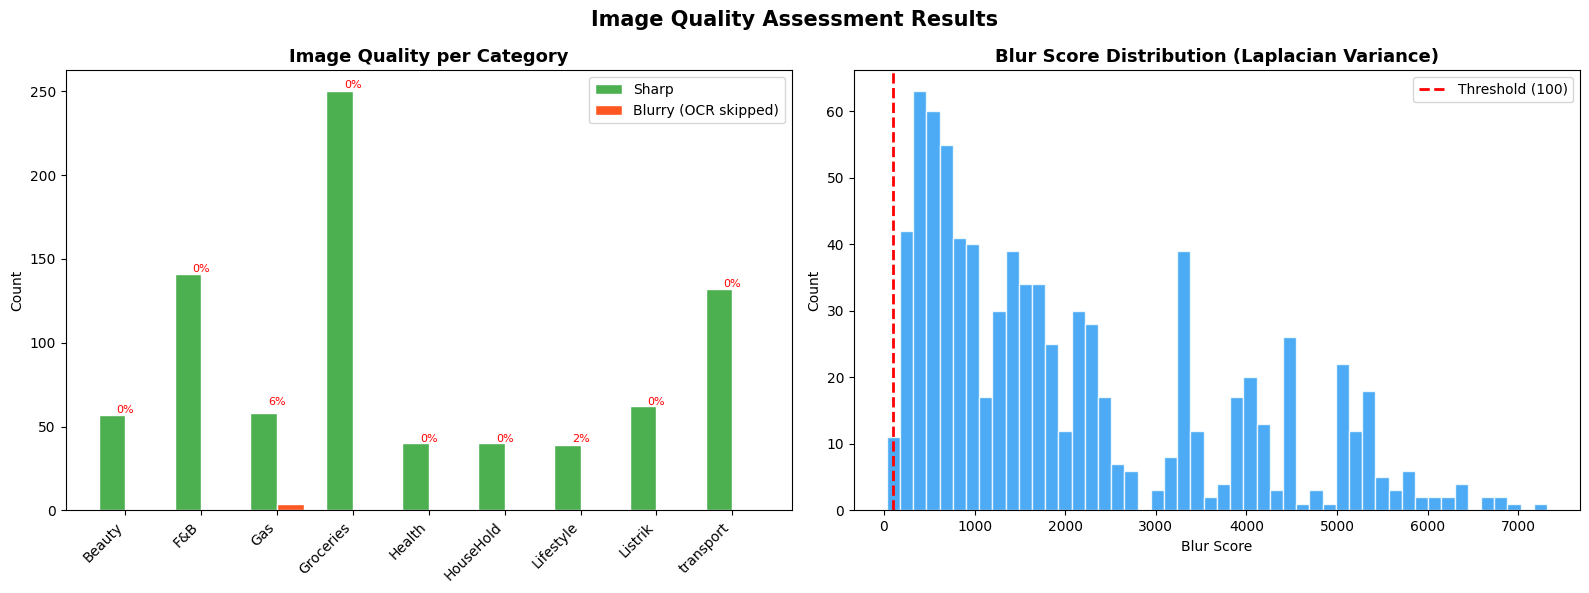

✅ Blur statistics plot saved


In [22]:
# --- Visualization 1: Blur statistics per category ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

blur_df = pd.DataFrame(blur_stats)
x = np.arange(len(CLASSES))
width = 0.35
axes[0].bar(x - width/2, blur_df['sharp'], width, label='Sharp', color='#4CAF50', edgecolor='white')
axes[0].bar(x + width/2, blur_df['blurry'], width, label='Blurry (OCR skipped)', color='#FF5722', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASSES, rotation=45, ha='right')
axes[0].set_title('Image Quality per Category', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].legend()
for i, row in blur_df.iterrows():
    axes[0].text(i, row['total'] + 1, f"{row['pct_blurry']:.0f}%", ha='center', fontsize=8, color='red')

# Blur score distribution
axes[1].hist(dataset_text['blur_score'], bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
axes[1].axvline(x=BLUR_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold ({BLUR_THRESHOLD})')
axes[1].set_title('Blur Score Distribution (Laplacian Variance)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Blur Score')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Image Quality Assessment Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'blur_statistics.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Blur statistics plot saved")

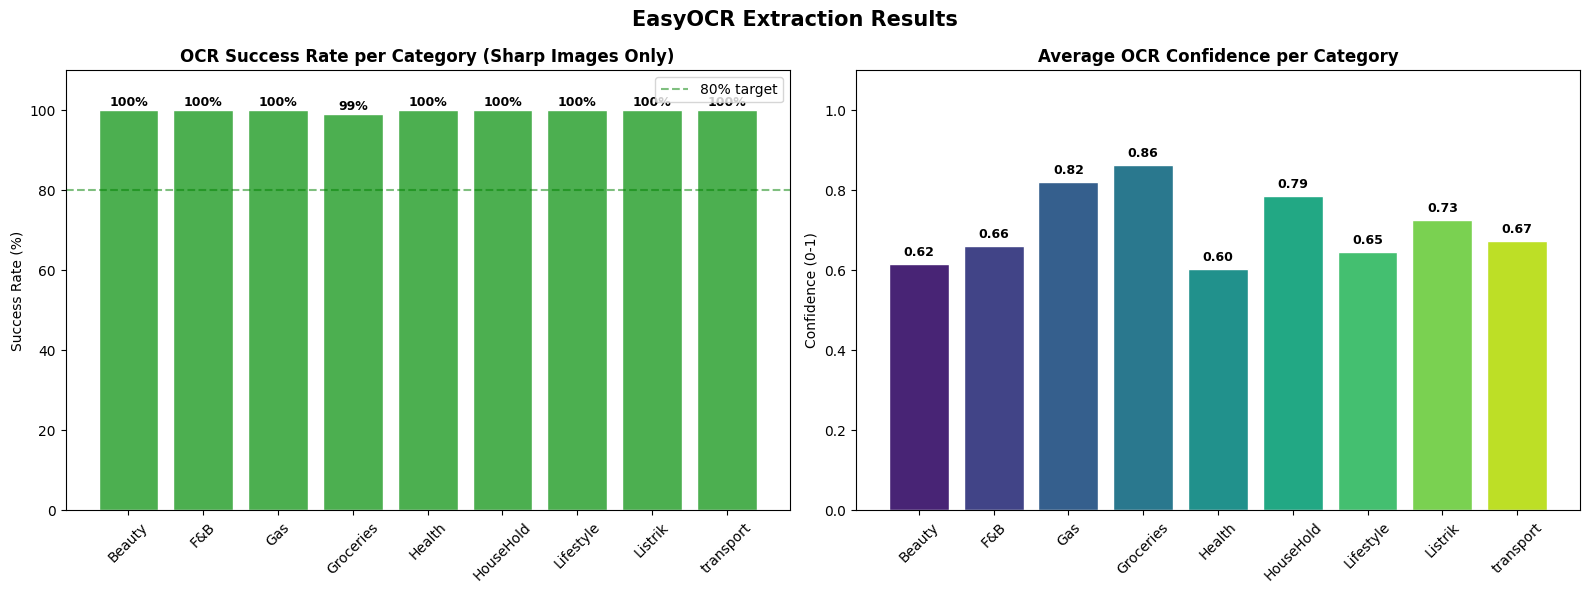

✅ OCR success rate plot saved


In [23]:
# --- Visualization 2: OCR success rate per category ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# OCR success rate (has text > 0)
success_rates = []
for cls in CLASSES:
    cls_data = dataset_text[dataset_text['category'] == cls]
    cls_sharp = cls_data[~cls_data['is_blurry']]
    rate = (cls_sharp['text_length'] > 0).mean() * 100 if len(cls_sharp) > 0 else 0
    success_rates.append(rate)

colors_sr = ['#4CAF50' if r >= 80 else '#FF9800' if r >= 50 else '#FF5722' for r in success_rates]
bars = axes[0].bar(CLASSES, success_rates, color=colors_sr, edgecolor='white')
axes[0].set_title('OCR Success Rate per Category (Sharp Images Only)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Success Rate (%)')
axes[0].set_ylim(0, 110)
axes[0].axhline(y=80, color='green', linestyle='--', alpha=0.5, label='80% target')
for bar, rate in zip(bars, success_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                 f'{rate:.0f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Average OCR confidence per category
avg_conf = dataset_text[~dataset_text['is_blurry']].groupby('category')['ocr_confidence'].mean().reindex(CLASSES, fill_value=0)
axes[1].bar(CLASSES, avg_conf.values, color=sns.color_palette("viridis", len(CLASSES)), edgecolor='white')
axes[1].set_title('Average OCR Confidence per Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Confidence (0-1)')
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(avg_conf.values):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('EasyOCR Extraction Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'ocr_success_rates.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ OCR success rate plot saved")

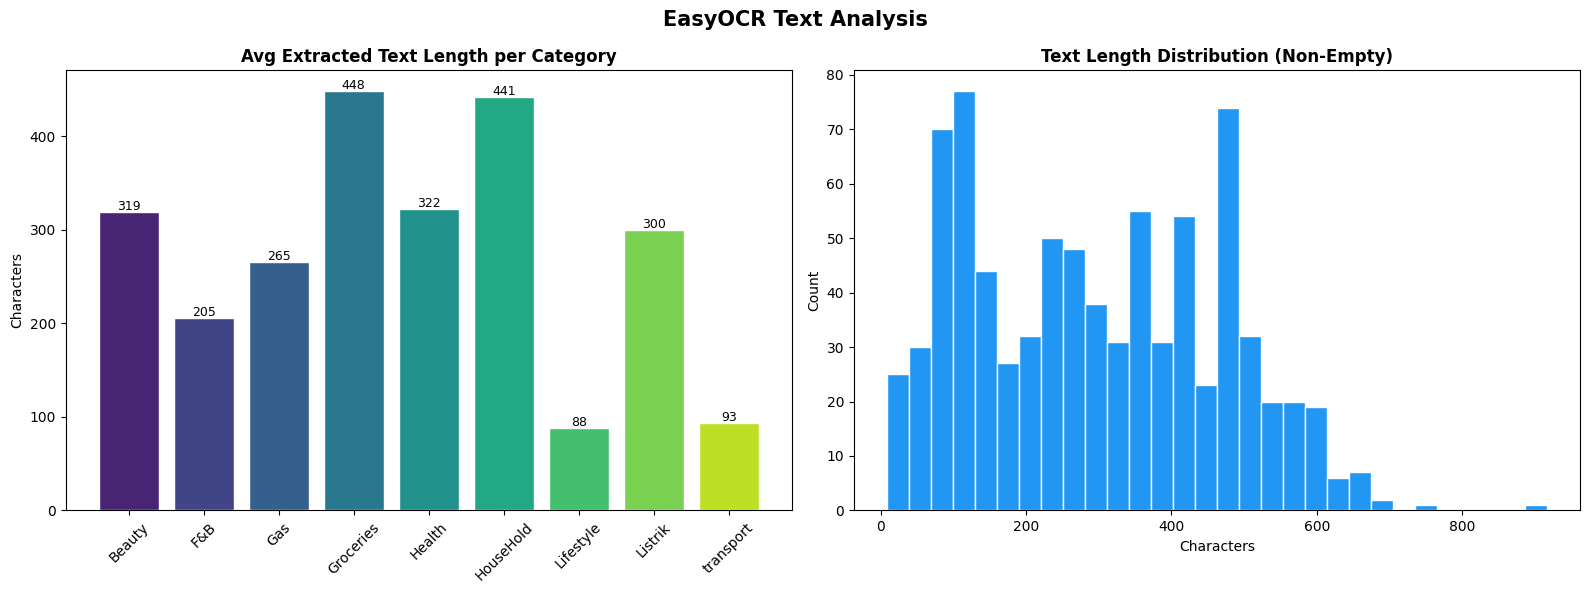

✅ OCR text analysis plot saved


In [24]:
# --- Visualization 3: Text length analysis ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avg_len = dataset_text.groupby('category')['text_length'].mean().reindex(CLASSES)
axes[0].bar(CLASSES, avg_len.values, color=sns.color_palette("viridis", len(CLASSES)), edgecolor='white')
axes[0].set_title('Avg Extracted Text Length per Category', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Characters')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(avg_len.values):
    axes[0].text(i, v + 2, f'{v:.0f}', ha='center', fontsize=9)

text_with_content = dataset_text[dataset_text['text_length'] > 0]['text_length']
if len(text_with_content) > 0:
    axes[1].hist(text_with_content, bins=30, color='#2196F3', edgecolor='white')
axes[1].set_title('Text Length Distribution (Non-Empty)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Count')

plt.suptitle('EasyOCR Text Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'ocr_text_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ OCR text analysis plot saved")

In [25]:
# --- Sample OCR results per category ---
print("\n📝 Sample Extracted Text per Category:")
print("=" * 80)
for cls in CLASSES:
    cls_data = dataset_text[dataset_text['category'] == cls]
    # Show one with text if available
    with_text = cls_data[cls_data['text_length'] > 0]
    if len(with_text) > 0:
        row = with_text.iloc[0]
        preview = row['extracted_text'][:80].replace('\n', ' ')
        blur_flag = "BLURRY" if row['is_blurry'] else "SHARP"
        print(f"  {cls:12s} [{blur_flag}] conf={row['ocr_confidence']:.2f} | {preview}")
    else:
        print(f"  {cls:12s} [NO TEXT] — all images either blurry or OCR failed")


📝 Sample Extracted Text per Category:
  Beauty       [SHARP] conf=0.62 | 10 df tlk npap indy park. gedun lanta dan jalan houlcvand binaro jaya blok sckto
  F&B          [SHARP] conf=0.51 | frecelpt 12 11 2023 order xhrlxlkuj host check xhrlklkuj area pket cheesewhopper
  Gas          [SHARP] conf=0.88 | spbu 45 507 26 jend sudirman no 57 sumowono tip. jumaat 24 apri 2026 14 : 48 19 
  Groceries    [SHARP] conf=0.91 | sndomaet ks tubun jl ks tubun no 05 rt02 kel temanggung kec temanggung kab teman
  Health       [SHARP] conf=0.60 | bulenr faktur penjualan satu dental summarecon bekasi unvoice no tanggal 08 janu
  HouseHold    [SHARP] conf=0.84 | pt aspirasi hidup indonesia tbk azko mall pekanbaru phone sms ahi carceahi id np
  Lifestyle    [SHARP] conf=0.61 | 02 428 020 3 021 3753321 total rp 698 0oo 673 con a 829 fo 17 lain 520 220 02 04
  Listrik      [SHARP] conf=0.88 | m commerce: 24 02 2026 pln prabayar dari rekening no meter rp bayar rp 103 000 s
  transport    [SHARP] conf=0.58 

## 1.8 — OCR Pseudo-Labeling from Real Receipt Images

In [26]:
import easyocr
import cv2
import os
import numpy as np
import pandas as pd
from pathlib import Path

reader = easyocr.Reader(['id', 'en'], gpu=True)

# PROJECT_ROOT sudah di-set oleh mount cell di atas
try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'data', '_ocr_real_crops')
os.makedirs(OUTPUT_DIR, exist_ok=True)

CATEGORIES = ["Beauty", "F&B", "Gas", "Groceries",
              "Health", "HouseHold", "Lifestyle", "Listrik"]

all_image_paths = []
for cat in CATEGORIES:
    cat_dir = os.path.join(DATA_DIR, cat)
    if os.path.exists(cat_dir):
        for ext in ['*.jpg', '*.jpeg', '*.png']:
            all_image_paths.extend(Path(cat_dir).rglob(ext))

print(f"Total foto struk: {len(all_image_paths)}")

# ─────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────
CROP_PADDING   = 10       # FIX #1: naik dari 4 → 10 agar huruf pinggir tidak kepotong
MIN_CROP_W     = 30       # FIX #2: filter crop terlalu kecil (lebar min px)
MIN_CROP_H     = 12       # FIX #2: filter crop terlalu kecil (tinggi min px)
LINE_Y_THRESH  = 12       # FIX #3: jarak vertikal max (px) untuk merge bbox ke 1 baris
TARGET_W       = 400
TARGET_H       = 50
CONF_THRESHOLD = 0.7
MIN_LEN        = 3
MAX_LEN        = 20

import string
CHARS = string.digits + string.ascii_uppercase + \
        string.ascii_lowercase + ' .,:-/()%'


# ─────────────────────────────────────────────────────────────
# FIX #1 + #3: merge_lines_by_y — gabungkan bbox yang y-nya
# berdekatan menjadi satu line-level detection.
# EasyOCR kadang split 1 baris jadi beberapa word-bbox,
# terutama di struk dengan spasi antar huruf.
# ─────────────────────────────────────────────────────────────
def merge_lines_by_y(results, y_thresh=LINE_Y_THRESH):
    """
    Merge EasyOCR results yang berada pada y yang sama (1 baris)
    menjadi satu entry dengan bbox gabungan dan teks gabungan.

    results: list of (bbox, text, conf) dari EasyOCR
    returns: list of (merged_bbox, merged_text, avg_conf)
    """
    if not results:
        return []

    # Sort by y-center dulu
    def y_center(r):
        bbox = r[0]
        return (bbox[0][1] + bbox[2][1]) / 2

    sorted_results = sorted(results, key=y_center)

    groups = []
    current_group = [sorted_results[0]]

    for item in sorted_results[1:]:
        prev_y = y_center(current_group[-1])
        curr_y = y_center(item)
        if abs(curr_y - prev_y) <= y_thresh:
            current_group.append(item)
        else:
            groups.append(current_group)
            current_group = [item]
    groups.append(current_group)

    merged = []
    for group in groups:
        # Sort dalam group by x (kiri ke kanan)
        group_sorted = sorted(group, key=lambda r: r[0][0][0])

        # Gabungkan teks
        texts = [r[1] for r in group_sorted]
        confs = [r[2] for r in group_sorted]
        merged_text = ' '.join(texts)
        avg_conf = float(np.mean(confs))

        # Gabungkan bbox: ambil pojok paling luar
        all_pts = [pt for r in group_sorted for pt in r[0]]
        all_pts = np.array(all_pts, dtype=np.float32)
        x_min = all_pts[:, 0].min()
        x_max = all_pts[:, 0].max()
        y_min = all_pts[:, 1].min()
        y_max = all_pts[:, 1].max()
        merged_bbox = [
            [x_min, y_min],
            [x_max, y_min],
            [x_max, y_max],
            [x_min, y_max]
        ]
        merged.append((merged_bbox, merged_text, avg_conf))

    return merged


# ─────────────────────────────────────────────────────────────
# FIX #1: crop_line dengan padding lebih besar + perspektif
# ─────────────────────────────────────────────────────────────
def crop_line(image, bbox, padding=CROP_PADDING):
    """
    Crop baris teks dengan perspektif transform + padding lebih besar.
    padding=10 (naik dari 4) agar huruf di tepi bbox tidak kepotong.
    """
    pts = np.array(bbox, dtype=np.float32)

    if pts.shape != (4, 2):
        x_min = max(0, int(pts[:, 0].min()) - padding)
        x_max = min(image.shape[1], int(pts[:, 0].max()) + padding)
        y_min = max(0, int(pts[:, 1].min()) - padding)
        y_max = min(image.shape[0], int(pts[:, 1].max()) + padding)
        return image[y_min:y_max, x_min:x_max]

    # Expand bbox dengan padding sebelum transform
    cx = pts[:, 0].mean()
    cy = pts[:, 1].mean()
    for i in range(4):
        dx = pts[i, 0] - cx
        dy = pts[i, 1] - cy
        norm = max(np.sqrt(dx**2 + dy**2), 1e-6)
        pts[i, 0] = np.clip(pts[i, 0] + (dx / norm) * padding, 0, image.shape[1] - 1)
        pts[i, 1] = np.clip(pts[i, 1] + (dy / norm) * padding, 0, image.shape[0] - 1)

    width = int(max(
        np.linalg.norm(pts[0] - pts[1]),
        np.linalg.norm(pts[2] - pts[3])
    ))
    height = int(max(
        np.linalg.norm(pts[0] - pts[3]),
        np.linalg.norm(pts[1] - pts[2])
    ))

    width  = max(5, min(width,  image.shape[1]))
    height = max(5, min(height, image.shape[0]))

    dst = np.array([
        [0, 0],
        [width - 1, 0],
        [width - 1, height - 1],
        [0, height - 1]
    ], dtype=np.float32)

    M = cv2.getPerspectiveTransform(pts, dst)
    warped = cv2.warpPerspective(
        image, M, (width, height),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REPLICATE
    )
    return warped


# ─────────────────────────────────────────────────────────────
# FIX #2: filter minimum size sebelum resize
# ─────────────────────────────────────────────────────────────
def is_crop_valid(crop, min_w=MIN_CROP_W, min_h=MIN_CROP_H):
    """Return False kalau crop terlalu kecil untuk OCR training."""
    if crop is None or crop.size == 0:
        return False
    h, w = crop.shape[:2]
    return w >= min_w and h >= min_h


# resize_with_padding tetap sama (sudah benar)
def resize_with_padding(crop, target_w=TARGET_W, target_h=TARGET_H):
    """Resize dengan aspect ratio preserved + padding putih di kanan."""
    if len(crop.shape) == 3:
        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    else:
        gray = crop.copy()

    h, w = gray.shape
    scale = target_h / h
    new_w = int(w * scale)

    if new_w > target_w:
        scale = target_w / w
        new_h = int(h * scale)
        new_w = target_w
        resized = cv2.resize(gray, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    else:
        resized = cv2.resize(gray, (new_w, target_h), interpolation=cv2.INTER_LINEAR)
        new_h = target_h

    canvas = np.ones((target_h, target_w), dtype=np.uint8) * 255
    y_offset = (target_h - new_h) // 2
    canvas[y_offset:y_offset + new_h, :new_w] = resized
    return canvas


def clean_label(text, charset):
    return ''.join(c for c in text if c in charset)


# ─────────────────────────────────────────────────────────────
# MAIN LOOP
# ─────────────────────────────────────────────────────────────
records = []
saved_count = 0
skip_blur = 0
skip_small = 0
skip_conf = 0
skip_label = 0

for idx, img_path in enumerate(all_image_paths):
    img = cv2.imread(str(img_path))
    if img is None:
        continue

    # Blur detection
    gray_full = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur_score = cv2.Laplacian(gray_full, cv2.CV_64F).var()
    if blur_score < 50:
        skip_blur += 1
        continue

    try:
        raw_results = reader.readtext(str(img_path), detail=1)
    except Exception:
        continue

    # FIX #3: merge word-bbox ke line-level
    line_results = merge_lines_by_y(raw_results, y_thresh=LINE_Y_THRESH)

    for line_idx, (bbox, text, conf) in enumerate(line_results):
        if conf < CONF_THRESHOLD:
            skip_conf += 1
            continue

        cleaned = clean_label(text, CHARS).strip()

        # Label filters
        if len(cleaned) < MIN_LEN or len(cleaned) > MAX_LEN:
            skip_label += 1
            continue
        if cleaned.isdigit() and len(cleaned) > 8:
            skip_label += 1
            continue
        if len(set(cleaned.replace(' ', ''))) < 2:
            skip_label += 1
            continue

        # Crop dengan padding lebih besar
        crop = crop_line(img, bbox, padding=CROP_PADDING)

        # FIX #2: filter crop terlalu kecil
        if not is_crop_valid(crop):
            skip_small += 1
            continue

        crop_resized = resize_with_padding(crop, TARGET_W, TARGET_H)

        filename = f"real_{idx:04d}_line{line_idx:02d}.png"
        save_path = os.path.join(OUTPUT_DIR, filename)
        cv2.imwrite(save_path, crop_resized)

        records.append({
            'image_path': save_path,
            'label':      cleaned,
            'confidence': conf,
            'source':     str(img_path)
        })
        saved_count += 1

    if (idx + 1) % 50 == 0:
        print(f"  [{idx+1}/{len(all_image_paths)}] saved={saved_count} "
              f"| skip_blur={skip_blur} skip_small={skip_small} "
              f"skip_conf={skip_conf} skip_label={skip_label}")

# Simpan manifest
df = pd.DataFrame(records)
manifest_path = os.path.join(PROJECT_ROOT, 'data', '_csv', 'ocr_real_labels.csv')
df.to_csv(manifest_path, index=False)

print(f"""
=====================================
HASIL PSEUDO-LABELING v2 (FIXED)
=====================================
Total foto         : {len(all_image_paths)}
Skip (blur)        : {skip_blur}
Skip (crop kecil)  : {skip_small}  ← FIX #2
Skip (conf < 0.7)  : {skip_conf}
Skip (label filter): {skip_label}
Total crops saved  : {saved_count}
Manifest saved     : {manifest_path}
=====================================
""")
print(df[['label', 'confidence']].head(10).to_string())


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Total foto struk: 693
  [50/693] saved=90 | skip_blur=0 skip_small=0 skip_conf=1092 skip_label=88
  [100/693] saved=210 | skip_blur=0 skip_small=0 skip_conf=2012 skip_label=127
  [150/693] saved=392 | skip_blur=0 skip_small=0 skip_conf=2734 skip_label=210
  [200/693] saved=638 | skip_blur=0 skip_small=0 skip_conf=3300 skip_label=324
  [250/693] saved=966 | skip_blur=1 skip_small=0 skip_conf=3614 skip_label=545
  [300/693] saved=1251 | skip_blur=1 skip_small=0 skip_conf=3939 skip_label=873
  [350/693] saved=1508 | skip_blur=1 skip_small=0 skip_conf=4072 skip_label=1386
  [400/693] saved=1802 | skip_blur=1 skip_small=0 skip_conf=4136 skip_label=1958
  [450/693] saved=2092 | skip_blur=1 skip_small=0 skip_conf=4202 skip_label=2519
  [500/693] saved=2320 | skip_blur=1 skip_small=0 skip_conf=4554 skip_label=2844
  [550/693] saved=2419 | skip_blur=1 skip_small=0 skip_conf=5223 skip_label=3018
  [600/693] saved=2698 | skip_blur=1 skip_small=0 skip_conf=5788 skip_label=3319
  [650/693] saved=27

## 1.9 — Visualisasi Hasil Pseudo-Labeling

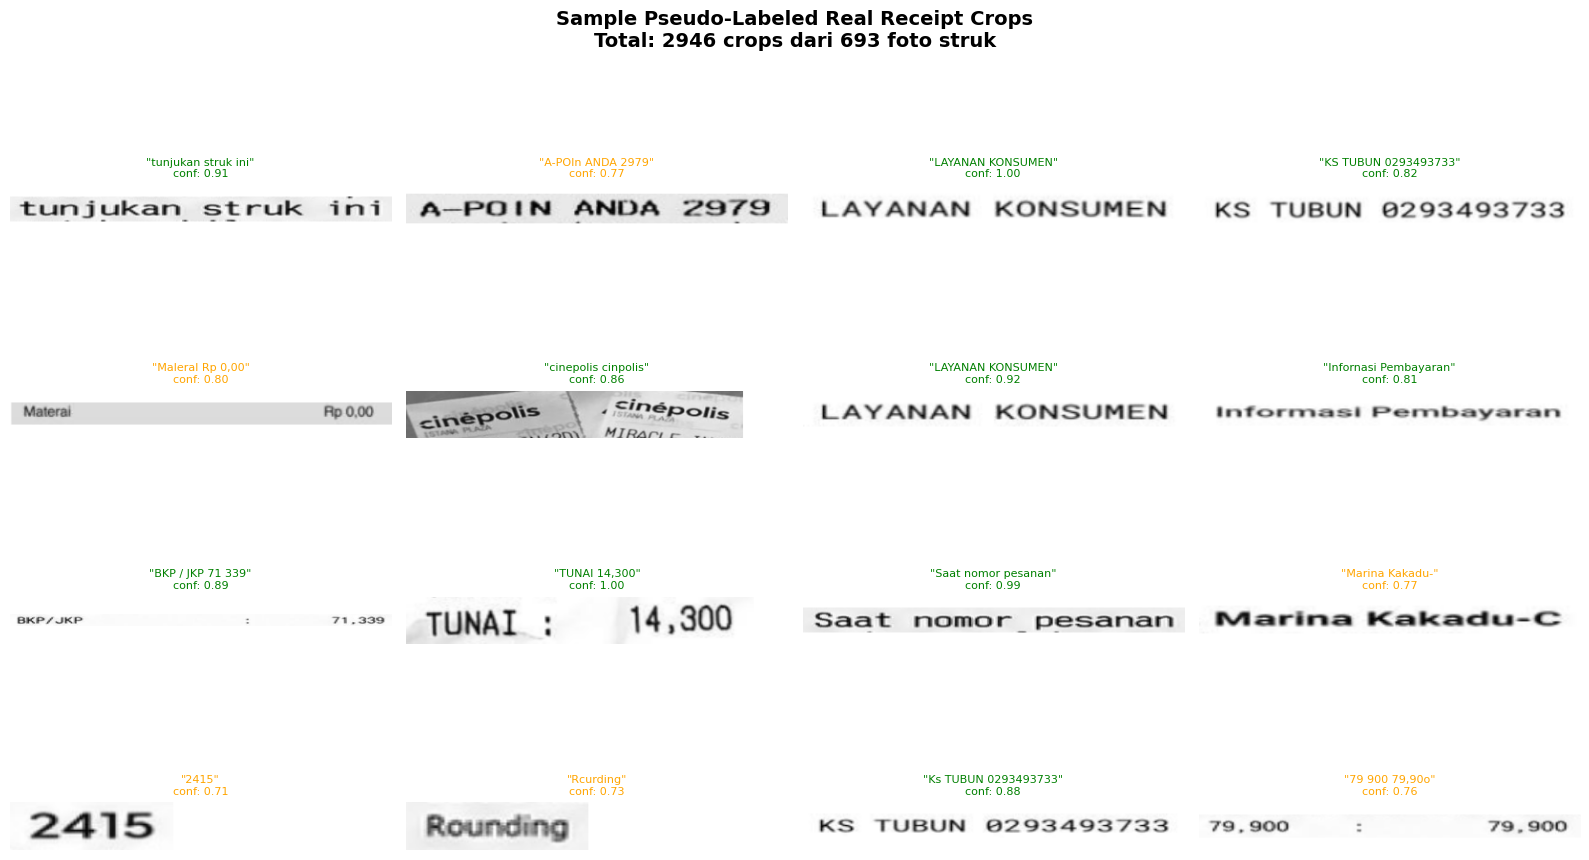

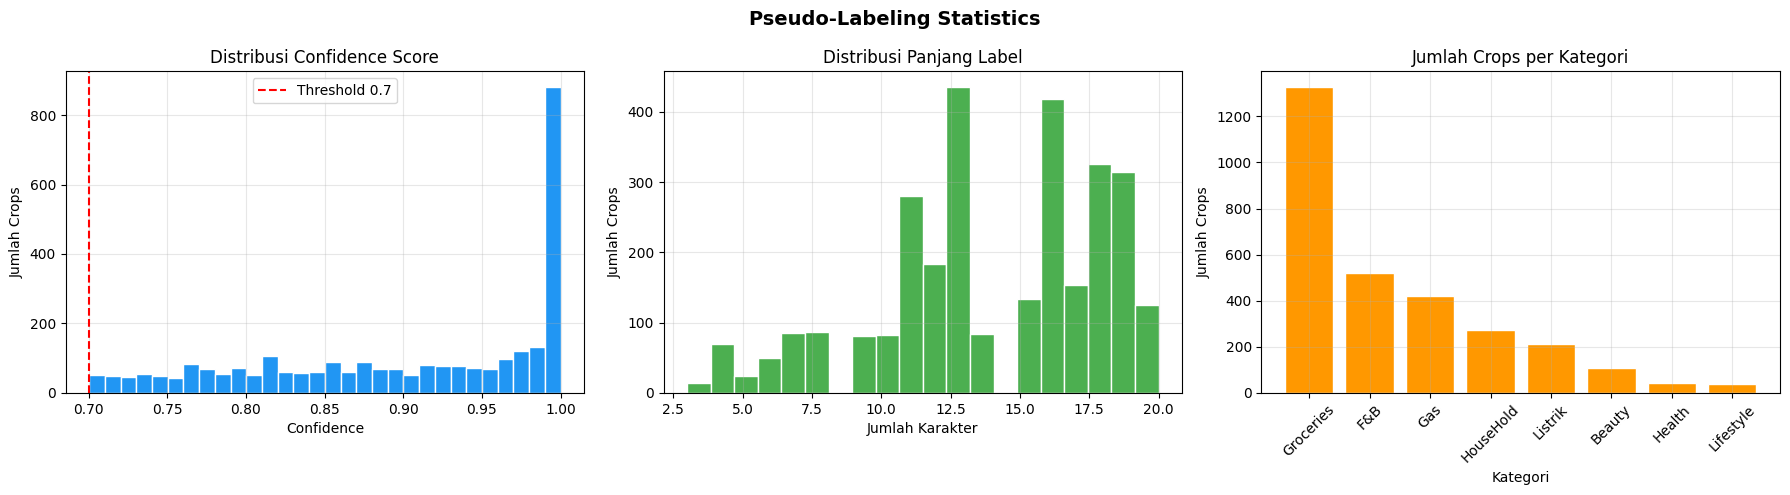


STATISTIK PSEUDO-LABELING
Total crops          : 2946
Confidence rata-rata : 0.903
Confidence > 0.9     : 1662 (56.4%)
Confidence 0.7-0.9   : 1284
Panjang label rata2  : 14.0 karakter
Label terpendek      : 3 karakter
Label terpanjang     : 20 karakter

Per Kategori:
category
Groceries    1329
F&B           519
Gas           422
HouseHold     272
Listrik       214
Beauty        107
Health         44
Lifestyle      39



In [27]:
import random

# ============================================================
# VISUALISASI HASIL PSEUDO-LABELING
# ============================================================

fig, axes = plt.subplots(4, 4, figsize=(16, 10))
fig.suptitle(f'Sample Pseudo-Labeled Real Receipt Crops\n'
             f'Total: {len(df)} crops dari {len(all_image_paths)} foto struk', 
             fontsize=14, fontweight='bold')

# Ambil 16 sample random
sample_df = df.sample(min(16, len(df)), random_state=42)

for idx, (ax, (_, row)) in enumerate(zip(axes.flat, sample_df.iterrows())):
    img = cv2.imread(row['image_path'])
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
    ax.set_title(f'"{row["label"]}"\nconf: {row["confidence"]:.2f}', 
                fontsize=8, color='green' if row['confidence'] > 0.8 else 'orange')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'data', '_processed', 
            'ocr_pseudo_label_samples.png'), dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# VISUALISASI DISTRIBUSI CONFIDENCE
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Pseudo-Labeling Statistics', fontsize=14, fontweight='bold')

# Plot 1 — Histogram confidence
axes[0].hist(df['confidence'], bins=30, color='#2196F3', edgecolor='white')
axes[0].axvline(x=0.7, color='red', linestyle='--', label='Threshold 0.7')
axes[0].set_title('Distribusi Confidence Score')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Jumlah Crops')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2 — Distribusi panjang label
label_lengths_dist = df['label'].str.len()
axes[1].hist(label_lengths_dist, bins=20, color='#4CAF50', edgecolor='white')
axes[1].set_title('Distribusi Panjang Label')
axes[1].set_xlabel('Jumlah Karakter')
axes[1].set_ylabel('Jumlah Crops')
axes[1].grid(alpha=0.3)

# Plot 3 — Jumlah crops per kategori
df['category'] = df['source'].apply(
    lambda x: next((cat for cat in CATEGORIES if cat.lower() in x.lower()), 'Unknown')
)
cat_counts = df['category'].value_counts()
axes[2].bar(cat_counts.index, cat_counts.values, color='#FF9800', edgecolor='white')
axes[2].set_title('Jumlah Crops per Kategori')
axes[2].set_xlabel('Kategori')
axes[2].set_ylabel('Jumlah Crops')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'data', '_processed',
            'ocr_pseudo_label_stats.png'), dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# RINGKASAN STATISTIK
# ============================================================

print(f"""
=====================================
STATISTIK PSEUDO-LABELING
=====================================
Total crops          : {len(df)}
Confidence rata-rata : {df['confidence'].mean():.3f}
Confidence > 0.9     : {(df['confidence'] > 0.9).sum()} ({(df['confidence'] > 0.9).mean()*100:.1f}%)
Confidence 0.7-0.9   : {((df['confidence'] >= 0.7) & (df['confidence'] < 0.9)).sum()}
Panjang label rata2  : {df['label'].str.len().mean():.1f} karakter
Label terpendek      : {df['label'].str.len().min()} karakter
Label terpanjang     : {df['label'].str.len().max()} karakter

Per Kategori:
{cat_counts.to_string()}
=====================================
""")

# Cap maksimal 2000 crops per kategori

In [28]:
# Cap maksimal 2000 crops per kategori
MAX_PER_CAT = 2000

df_balanced = df.groupby('category').apply(
    lambda x: x.sample(min(len(x), MAX_PER_CAT), random_state=42)
).reset_index(drop=True)

print(f"Sebelum balancing: {len(df)}")
print(f"Sesudah balancing: {len(df_balanced)}")
print(df_balanced['category'].value_counts())

# Simpan ulang manifest yang sudah balanced
df_balanced.to_csv(manifest_path, index=False)
print("✅ Balanced manifest saved")

Sebelum balancing: 2946
Sesudah balancing: 2946
category
Groceries    1329
F&B           519
Gas           422
HouseHold     272
Listrik       214
Beauty        107
Health         44
Lifestyle      39
Name: count, dtype: int64
✅ Balanced manifest saved


## LAPORAN

In [29]:
print(f"""
{'=' * 60}
LAPORAN: Notebook 01 — Preprocessing & EasyOCR
{'=' * 60}

IMPROVEMENTS:
- Replaced Tesseract OCR with EasyOCR (id+en, GPU=True)
- Added blur detection (Laplacian variance, threshold={BLUR_THRESHOLD})
- Added CLAHE normalization for contrast enhancement
- Added image upscaling for small images (width < 800px → 2x)
- Added aggressive text cleaning (remove barcodes, noise)

RESULTS:
- Total images:      {len(all_filepaths)}
- Split:             70/15/15 stratified
- Equalisasi:        {TARGET_PER_CLASS}/kelas (train)
- Blurry images:     {blurry_total}/{total} ({blurry_total/total*100:.1f}%)
- OCR extracted:     {has_text}/{total} ({has_text/total*100:.1f}%)
- Confidence filter: > {OCR_CONFIDENCE_THRESHOLD}

OUTPUT FILES:
- data/_csv/split_manifest.csv
- data/_processed/dataset_text.csv (with blur_score, is_blurry, ocr_confidence)
- data/_processed/blur_statistics.png
- data/_processed/ocr_success_rates.png
- data/_processed/ocr_text_analysis.png
{'=' * 60}
""")


LAPORAN: Notebook 01 — Preprocessing & EasyOCR

IMPROVEMENTS:
- Replaced Tesseract OCR with EasyOCR (id+en, GPU=True)
- Added blur detection (Laplacian variance, threshold=100)
- Added CLAHE normalization for contrast enhancement
- Added image upscaling for small images (width < 800px → 2x)
- Added aggressive text cleaning (remove barcodes, noise)

RESULTS:
- Total images:      825
- Split:             70/15/15 stratified
- Equalisasi:        200/kelas (train)
- Blurry images:     6/825 (0.7%)
- OCR extracted:     817/825 (99.0%)
- Confidence filter: > 0.3

OUTPUT FILES:
- data/_csv/split_manifest.csv
- data/_processed/dataset_text.csv (with blur_score, is_blurry, ocr_confidence)
- data/_processed/blur_statistics.png
- data/_processed/ocr_success_rates.png
- data/_processed/ocr_text_analysis.png

